# mini-VLM Inference

Loads a trained connector checkpoint and generates captions for CIFAR-10 test images.

Pipeline: `CLIP ViT-B/32 (CLS token) → MLP Connector → SmolLM2-135M-Instruct`

Only the connector was trained. Everything else is frozen.

## 0. Project root & imports

In [2]:
import glob

import rootutils

root = rootutils.setup_root(".", indicator=".project-root", pythonpath=True)
print(f"Project root: {root}")

Project root: /Users/gsoykan/Desktop/yanan-desktop/inzva/applied-ai-10/mini-vlm


In [3]:
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, CLIPImageProcessor

from src.models.components.language_decoder import LanguageDecoder
from src.models.components.mlp_connector import MLPConnector
from src.models.components.vision_encoder import VisionEncoder
from src.models.mini_vlm_module import MiniVLMModule

DEVICE = (
    torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)
print(f"Device: {DEVICE}")

Device: mps


## 1. Config

In [3]:
VISION_MODEL = "openai/clip-vit-base-patch32"
LM_MODEL = "HuggingFaceTB/SmolLM2-135M-Instruct"
USER_PROMPT = "Describe this image briefly."
MAX_NEW_TOKENS = 20

# Auto-select the latest epoch checkpoint
ckpt_paths = sorted(glob.glob(str(root / "logs/mini_vlm_stage1/runs/*/checkpoints/epoch_*.ckpt")))
assert (
    ckpt_paths
), "No checkpoint found — train first: python src/train.py experiment=mini_vlm_cifar10"
CKPT_PATH = ckpt_paths[-1]
print(f"Checkpoint: {CKPT_PATH}")

Checkpoint: /Users/gsoykan/Desktop/yanan-desktop/inzva/applied-ai-10/mini-vlm/logs/mini_vlm_stage1/runs/2026-05-15_00-34-09/checkpoints/epoch_009.ckpt


## 2. Load model from checkpoint

The three frozen components are instantiated fresh, then the checkpoint's
`state_dict` is loaded directly with `weights_only=False`.

Why not `load_from_checkpoint`? The vision encoder, connector, and language
decoder are excluded from `save_hyperparameters` (they are large pretrained
models, not plain-Python config). Lightning can't reconstruct them from the
checkpoint alone without Hydra. We also need `weights_only=False` because
PyTorch 2.6 changed the default to `True`, which blocks `functools.partial`
objects stored in the checkpoint (the scheduler/optimizer partials from Hydra).

In [4]:
vision_encoder = VisionEncoder(model_name=VISION_MODEL, use_cls=True)
connector = MLPConnector(vision_dim=768, llm_dim=576, pool_size=None)
language_decoder = LanguageDecoder(model_name=LM_MODEL)

model = MiniVLMModule(
    vision_encoder=vision_encoder,
    connector=connector,
    language_decoder=language_decoder,
    optimizer=torch.optim.AdamW,  # required by __init__; unused at inference
)

# weights_only=False: checkpoint stores Hydra optimizer/scheduler partials;
# this file is ours so there is no untrusted-code risk.
raw_ckpt = torch.load(CKPT_PATH, weights_only=False, map_location="cpu")
model.load_state_dict(raw_ckpt["state_dict"])

model = model.to(DEVICE).eval()
print("Checkpoint loaded.")
print(f"Connector params: {sum(p.numel() for p in model.connector.parameters()):,}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 42893.60it/s]
[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias     

Checkpoint loaded.
Connector params: 776,832


## 3. Preprocessing helpers

In [5]:
image_processor = CLIPImageProcessor.from_pretrained(VISION_MODEL)
tokenizer = AutoTokenizer.from_pretrained(LM_MODEL)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Build the prompt prefix once — same format used during training
messages = [{"role": "user", "content": USER_PROMPT}]
prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
prompt_ids = torch.tensor(
    tokenizer.encode(prompt_text, add_special_tokens=False),
    dtype=torch.long,
)
print(f"Prompt prefix ({len(prompt_ids)} tokens):")
print(repr(prompt_text))

Prompt prefix (35 tokens):
'<|im_start|>system\nYou are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>\n<|im_start|>user\nDescribe this image briefly.<|im_end|>\n<|im_start|>assistant\n'


In [6]:
def preprocess(pil_image):
    """PIL Image → pixel_values [1, 3, 224, 224] on DEVICE."""
    pv = image_processor(images=pil_image.convert("RGB"), return_tensors="pt")["pixel_values"]
    return pv.to(DEVICE)


def generate(pil_image):
    """PIL Image → caption string."""
    with torch.no_grad():
        ids = model.generate_caption(
            preprocess(pil_image),
            prompt_ids=prompt_ids,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
        )  # [1, T]
    return tokenizer.decode(ids[0], skip_special_tokens=True).strip()

## 4. Load CIFAR-10 test images (one per class)

In [7]:
_CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

cifar_test = load_dataset("uoft-cs/cifar10", split="test")

samples = {}
for row in cifar_test:
    label = row["label"]
    if label not in samples:
        samples[label] = row
    if len(samples) == 10:
        break

print(f"Loaded one example per class ({len(samples)} total).")

Loaded one example per class (10 total).


## 5. Generate captions

In [8]:
results = []
for label_idx in range(10):
    row = samples[label_idx]
    img = row["img"].convert("RGB")
    caption = generate(img)
    reference = f"a photo of a {_CLASSES[label_idx]}"
    results.append((img, caption, reference))
    print(f"[{_CLASSES[label_idx]:>10s}]  {caption}")

[  airplane]  a photo of a airplane
[automobile]  a photo of a automobile
[      bird]  a photo of a bird
[       cat]  a photo of a cat
[      deer]  a photo of a deer
[       dog]  a photo of a dog
[      frog]  a photo of a frog
[     horse]  a photo of a horse
[      ship]  a photo of a ship
[     truck]  a photo of a truck


## 6. Visualise results

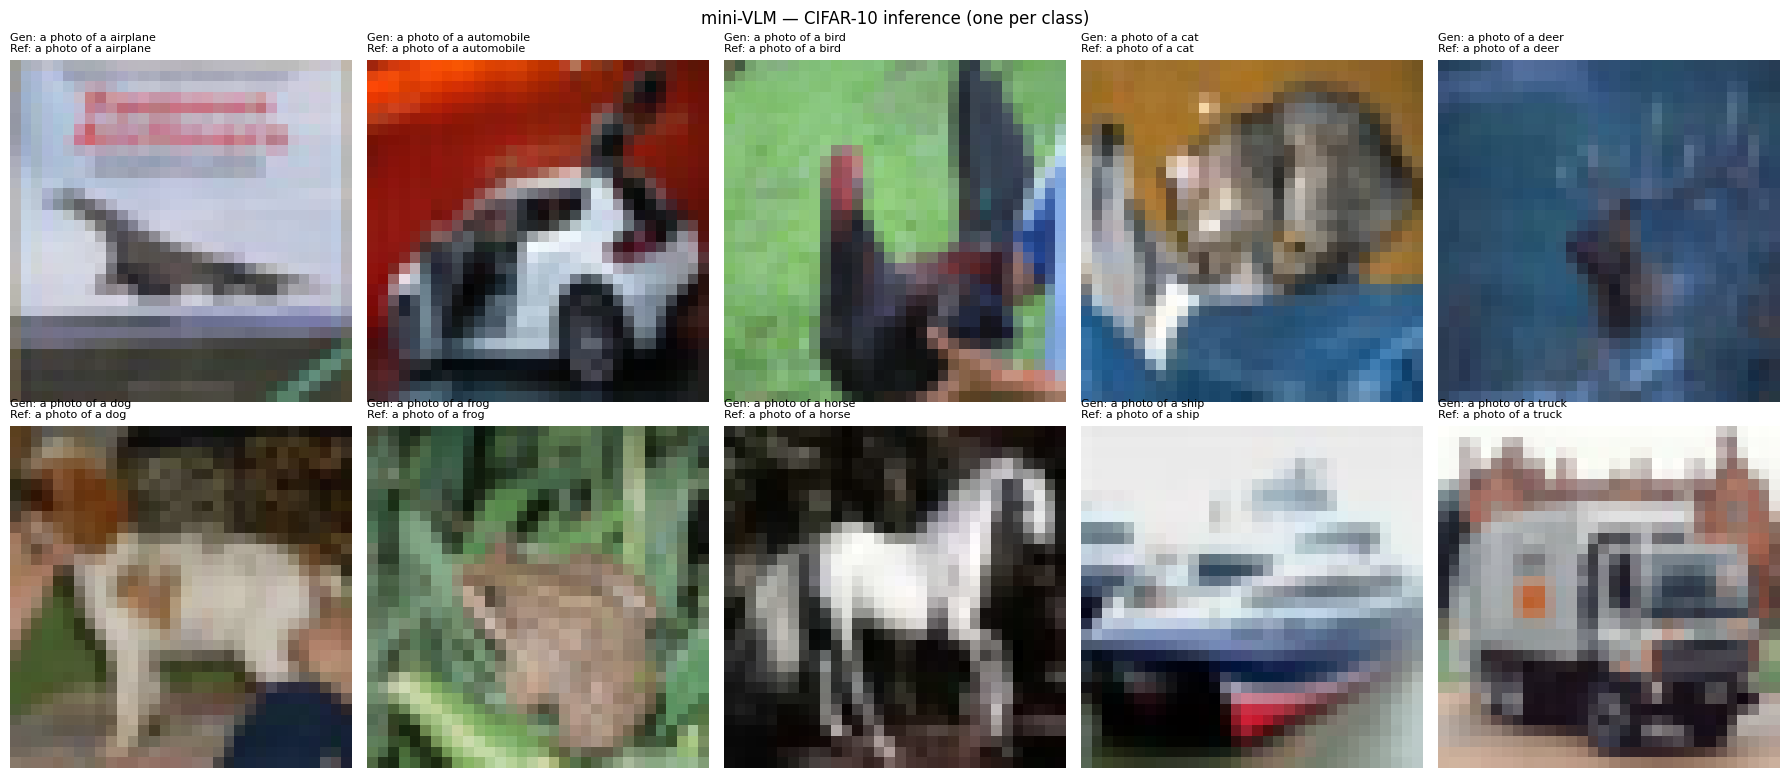

Saved inference_grid.png


In [9]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for ax, (img, caption, reference) in zip(axes, results, strict=False):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"Gen: {caption}\nRef: {reference}",
        fontsize=8,
        loc="left",
    )

fig.suptitle("mini-VLM — CIFAR-10 inference (one per class)", fontsize=12)
plt.tight_layout()
plt.savefig("inference_grid.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved inference_grid.png")

## 7. Try your own image

Generated    : A cat
Ground truth : a photo of a cat


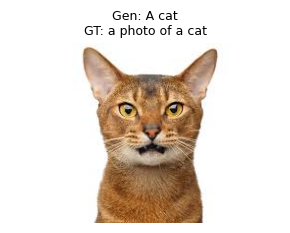

In [18]:
from PIL import Image

# Swap in any PIL image here, e.g.:
img = Image.open("img_5.png")
gt = "cat"
# row = cifar_test[random.randint(0, len(cifar_test) - 1)]
# img = row["img"].convert("RGB")
# gt  = _CLASSES[row["label"]]

caption = generate(img)
print(f"Generated    : {caption}")
print(f"Ground truth : a photo of a {gt}")

plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.axis("off")
plt.title(f"Gen: {caption}\nGT: a photo of a {gt}", fontsize=9)
plt.tight_layout()
plt.show()